In [10]:
# ==============================
# 1️⃣ Mount Google Drive (Colab)
# ==============================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# ==============================
# 2️⃣ Define Dataset Paths
# ==============================
train_file = '/content/drive/MyDrive/Datasets-final/UNSW-NB15/UNSW_NB15_testing-set.csv'
test_file  = '/content/drive/MyDrive/Datasets-final/UNSW-NB15/UNSW_NB15_training-set.csv'

# ==============================
# 3️⃣ Import Required Libraries
# ==============================
import pandas as pd

# ==============================
# 4️⃣ Load the Datasets
# ==============================
train_df = pd.read_csv(train_file)
test_df  = pd.read_csv(test_file)
selected_features=['ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'dinpkt', 'djit', 'dload', 'dloss', 'dmean', 'dpkts', 'dtcpb', 'dttl', 'dur', 'proto', 'rate', 'sbytes', 'service', 'sinpkt', 'sjit', 'sload', 'sloss', 'smean', 'spkts', 'state', 'stcpb', 'sttl', 'swin', 'synack', 'tcprtt','attack_cat','label','id']
# ==============================
# 5️⃣ Basic Inspection
# ==============================
train_df=train_df[selected_features]
test_df=test_df[selected_features]
print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

print("\nTraining Columns:")
print(train_df.columns)

print("\nSample Training Data:")
print(train_df.head())


Training Data Shape: (175341, 38)
Testing Data Shape: (82332, 38)

Training Columns:
Index(['ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src',
       'ct_state_ttl', 'dbytes', 'dinpkt', 'djit', 'dload', 'dloss', 'dmean',
       'dpkts', 'dtcpb', 'dttl', 'dur', 'proto', 'rate', 'sbytes', 'service',
       'sinpkt', 'sjit', 'sload', 'sloss', 'smean', 'spkts', 'state', 'stcpb',
       'sttl', 'swin', 'synack', 'tcprtt', 'attack_cat', 'label', 'id'],
      dtype='object')

Sample Training Data:
     ackdat  ct_dst_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  ct_src_dport_ltm  \
0  0.000000           1                 1               1                 1   
1  0.000000           1                 1               2                 1   
2  0.050439           2                 1               3                 1   
3  0.000000           2                 1               3                 1   
4  0.057234           2      

In [12]:
# =====================================
# 1️⃣ Combine Train and Test Datasets
# =====================================
import pandas as pd
import numpy as np

combined_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print("Combined Shape:", combined_df.shape)


# =====================================
# 2️⃣ Drop attack_cat (avoid leakage)
# =====================================
if 'attack_cat' in combined_df.columns:
    combined_df = combined_df.drop(columns=['attack_cat','id'])

print("Columns after dropping attack_cat:")
print(combined_df.columns)


# =====================================
# 3️⃣ Separate Features and Target
# =====================================
target_column = 'label'

X = combined_df.drop(columns=[target_column])
y = combined_df[target_column]

print("Feature Shape:", X.shape)
print("Target Distribution:\n", y.value_counts())


# =====================================
# 4️⃣ Encode Categorical Features
# =====================================
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print("Categorical columns encoded:", list(categorical_cols))

# =====================================
# 6️⃣ Stratified 80-20 Split
# =====================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# =====================================
# 5️⃣ Feature Scaling (FIT ONLY ON TRAIN)
# =====================================
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# # Fit only on training features
# scaler.fit(X_train)

# # Transform both train and test
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# print("Scaling completed without leakage.")
# =====================================
# 5️⃣ Feature Scaling (FIT ONLY ON TRAIN)
# =====================================
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit only on training features
scaler.fit(X_train)

# Transform both train and test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed without leakage.")



print("Train Shape:", X_train_scaled.shape)
print("Test Shape:", X_test_scaled.shape)

print("\nTrain Target Distribution:\n", pd.Series(y_train).value_counts())
print("\nTest Target Distribution:\n", pd.Series(y_test).value_counts())


Combined Shape: (257673, 38)
Columns after dropping attack_cat:
Index(['ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src',
       'ct_state_ttl', 'dbytes', 'dinpkt', 'djit', 'dload', 'dloss', 'dmean',
       'dpkts', 'dtcpb', 'dttl', 'dur', 'proto', 'rate', 'sbytes', 'service',
       'sinpkt', 'sjit', 'sload', 'sloss', 'smean', 'spkts', 'state', 'stcpb',
       'sttl', 'swin', 'synack', 'tcprtt', 'label'],
      dtype='object')
Feature Shape: (257673, 35)
Target Distribution:
 label
1    164673
0     93000
Name: count, dtype: int64
Categorical columns encoded: ['proto', 'service', 'state']
Scaling completed without leakage.
Train Shape: (206138, 35)
Test Shape: (51535, 35)

Train Target Distribution:
 label
1    131738
0     74400
Name: count, dtype: int64

Test Target Distribution:
 label
1    32935
0    18600
Name: count, dtype: int64


In [13]:


# # --- Data Before Preprocessing (First 5 Rows, Selected Columns) ---
# # 'combined_df_full' is available from prior execution and contains original values.
# # We will use columns from X, plus the 'label' column to match for comparison.
# columns_to_show_before = X.columns.tolist() + ['label']
# df_before_preprocessing = combined_df_full[columns_to_show_before].head(5)

# print("\n--- Data Before Preprocessing (First 5 Rows, Selected Columns) ---")
# print(df_before_preprocessing.to_markdown(index=False))


# # --- AFTER PREPROCESSING (First 5 rows of X_train_scaled and y_train) ---
# # feature_columns already contains the column names in the order they appear in X_train_scaled
# feature_columns = X.columns.tolist()

# # Create a DataFrame for the first 5 scaled training samples
# df_after_features = pd.DataFrame(X_train_scaled[:5], columns=feature_columns)

# # Get the corresponding y_train values for these samples
# # Since X_train_scaled are the first samples of X_train, we need y_train corresponding to them.
# df_after_labels = pd.Series(y_train.iloc[:5]).reset_index(drop=True)
# df_after_labels.name = 'label'

# # Combine features and labels
# df_after_preprocessing = pd.concat([df_after_features, df_after_labels], axis=1)

# print("\n--- Data After Preprocessing (First 5 Training Rows, Scaled Features) ---")
# print(df_after_preprocessing.to_markdown(index=False))

In [14]:
import tensorflow as tf
save_path = "/content/drive/MyDrive/Multiclass_Feature_Selection models"
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
# =====================================
# 1️⃣ Import Required Libraries
# =====================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# =====================================
# 2️⃣ Define Input Dimension
# =====================================
input_dim = X_train_scaled.shape[1]

# =====================================
# 3️⃣ Build Residual Block Function
# =====================================
def residual_block(x, units):
    shortcut = x

    x = layers.Dense(units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(units, activation=None)(x)
    x = layers.BatchNormalization()(x)

    # Match dimensions if needed
    if shortcut.shape[-1] != units:
        shortcut = layers.Dense(units)(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

# =====================================
# 4️⃣ Build Encoder Model
# =====================================
inputs = layers.Input(shape=(input_dim,))

x = layers.Dense(256, activation='relu')(inputs)
x = layers.BatchNormalization()(x)

x = residual_block(x, 256)
x = residual_block(x, 128)

# 🔥 Embedding Layer (IMPORTANT)
embedding = layers.Dense(64, activation='relu', name="embedding_layer")(x)

# Classification head
outputs = layers.Dense(1, activation='sigmoid')(embedding)

model = models.Model(inputs=inputs, outputs=outputs)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      9,216 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 64)        │      8,256 │ activation_1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ embedding_layer[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 235,521 (920.00 KB)

 Trainable params: 233,473 (912.00 KB)

 Non-trainable params: 2,048 (8.00 KB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9119 - auc: 0.9775 - loss: 0.1716 - val_accuracy: 0.9001 - val_auc: 0.9675 - val_loss: 0.2212
Epoch 2/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9243 - auc: 0.9833 - loss: 0.1486 - val_accuracy: 0.9092 - val_auc: 0.9807 - val_loss: 0.1815
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9281 - auc: 0.9848 - loss: 0.1428 - val_accuracy: 0.9158 - val_auc: 0.9793 - val_loss: 0.1744
Epoch 4/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9312 - auc: 0.9857 - loss: 0.1384 - val_accuracy: 0.9278 - val_auc: 0.9859 - val_loss: 0.1416
Epoch 5/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9326 - auc: 0.9862 - loss: 0.1360 - val_accuracy: 0.9301 - val_auc: 0.9862 - val_loss: 0.1365
Epoch 6/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9331 - auc: 0.9866 - loss: 0.1338 - val_accuracy: 0.9299 - val_auc: 0.9854 - val_loss: 0.1455
Epoch 7/50
403/403 ━━━━━━━━━━━━━━━━━━━

101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
===== Global DNN Evaluation ====
Accuracy  : 0.9354
Precision : 0.9447
Recall    : 0.9548
F1-Score  : 0.9497
ROC-AUC   : 0.9878

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.90      0.91     18600
           1       0.94      0.95      0.95     32935

    accuracy                           0.94     51535
   macro avg       0.93      0.93      0.93     51535
weighted avg       0.94      0.94      0.94     51535



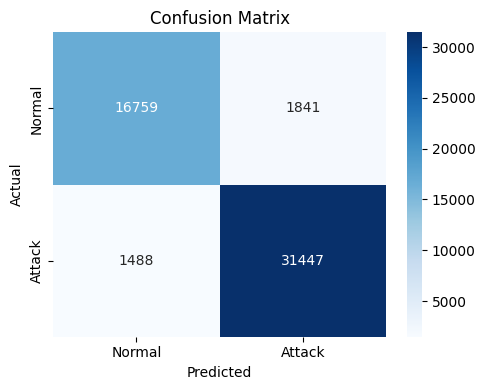

Confusion Matrix:
 [[16759  1841]
 [ 1488 31447]]


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Predict probabilities
y_pred_prob = model.predict(X_test_scaled, batch_size=512)

# Convert to binary (threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print("===== Global DNN Evaluation ====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4)) # Adjust figure size for better readability
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # Use seaborn.heatmap with annotations
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("Confusion Matrix:\n", cm)

In [19]:
import os

os.makedirs(save_path, exist_ok=True)

print("Directory created at:", save_path)

Directory created at: /content/drive/MyDrive/Multiclass_Feature_Selection models


In [20]:
encoder = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("embedding_layer").output
)
# Extract embeddings separately
Z_train = encoder.predict(X_train_scaled)
Z_test  = encoder.predict(X_test_scaled)

print("Train embedding shape:", Z_train.shape)
print("Test embedding shape:", Z_test.shape)



6442/6442 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Train embedding shape: (206138, 64)
Test embedding shape: (51535, 64)


In [21]:
print("Embedding shape train:", Z_train.shape)
print("Embedding shape test:", Z_test.shape)
import numpy as np

np.save(os.path.join(save_path, "embeddings_train.npy"), Z_train)
np.save(os.path.join(save_path, "embeddings_test.npy"), Z_test)
print("Embeddings saved to drive.")



Embedding shape train: (206138, 64)
Embedding shape test: (51535, 64)
Embeddings saved to drive.


In [22]:

model.save(os.path.join(save_path, "global_dnn_model.h5"))
print("Full DNN model saved.")


encoder.save(os.path.join(save_path, "global_encoder_model.h5"))
print("Encoder model saved.")


Full DNN model saved.
Encoder model saved.


In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Save scaler
joblib.dump(scaler, os.path.join(save_path, "scaler.pkl"))

# Save categorical column names
joblib.dump(categorical_cols, os.path.join(save_path, "categorical_columns.pkl"))

# Build and save LabelEncoders for categorical features (so inference can reuse mappings)
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # fit on combined_df if available, otherwise on X
    try:
        source_values = combined_df[col].astype(str).values
    except Exception:
        source_values = X[col].astype(str).values
    le.fit(source_values)
    encoders[col] = le

joblib.dump(encoders, os.path.join(save_path, "label_encoders.pkl"))

print("Scaler, categorical columns, and label encoders saved.")


Scaler and categorical column list saved.


In [24]:
X_train_full = np.hstack((X_train_scaled, Z_train))
X_test_full  = np.hstack((X_test_scaled, Z_test))
# Identify attack samples in TRAIN
train_attack_indices = np.where(y_train.values == 1)[0]

Z_train_attack = Z_train[train_attack_indices]
X_train_attack_full = X_train_full[train_attack_indices]


In [25]:
# Rebuild combined dataset (WITH attack_cat)
combined_df_full = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# Drop the 'id' column as it's not needed for the target variables
# It was previously removed for features (X) in an earlier step.
if 'id' in combined_df_full.columns:
    combined_df_full = combined_df_full.drop(columns=['id'])

print(combined_df_full)
# Binary target
y_binary = combined_df_full['label']

# Multi-class target
y_attack_cat = combined_df_full['attack_cat']

attack_label_encoder = LabelEncoder()

y_attack_cat_train = combined_df_full.loc[y_train.index, 'attack_cat']

attack_label_encoder.fit(
    y_attack_cat_train.iloc[train_attack_indices]
)

y_train_attack_encoded = attack_label_encoder.transform(
    y_attack_cat_train.iloc[train_attack_indices]
)

          ackdat  ct_dst_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
0       0.000000           1                 1               1   
1       0.000000           1                 1               2   
2       0.050439           2                 1               3   
3       0.000000           2                 1               3   
4       0.057234           2                 1              40   
...          ...         ...               ...             ...   
257668  0.000000           2                 1               2   
257669  0.073017           2                 1               1   
257670  0.000000           1                 1               1   
257671  0.000000           1                 1               1   
257672  0.000000           1                 1               1   

        ct_src_dport_ltm  ct_src_ltm  ct_srv_dst  ct_srv_src  ct_state_ttl  \
0                      1           1           1           1             0   
1                      1           1           6   

In [26]:
from sklearn.cluster import KMeans

num_attack_clusters = 3

kmeans_attack = KMeans(
    n_clusters=num_attack_clusters,
    random_state=42,
    n_init=20
)

train_attack_cluster_labels = kmeans_attack.fit_predict(Z_train_attack)

print("Train attack cluster distribution:",
      np.unique(train_attack_cluster_labels, return_counts=True))


Train attack cluster distribution: (array([0, 1, 2], dtype=int32), array([52600, 48308, 30830]))


In [27]:
import xgboost as xgb

num_classes = len(attack_label_encoder.classes_)
xgb_attack_models = {}

for cluster_id in range(num_attack_clusters):

    cluster_indices = np.where(train_attack_cluster_labels == cluster_id)[0]

    X_cluster = X_train_attack_full[cluster_indices]
    y_cluster = y_train_attack_encoded[cluster_indices]

    print(f"\nCluster {cluster_id}")
    print("Samples:", X_cluster.shape[0])
    print("Classes:", np.unique(y_cluster))

    model_xgb = xgb.XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        random_state=42
    )

    model_xgb.fit(X_cluster, y_cluster)

    xgb_attack_models[cluster_id] = model_xgb



Cluster 0
Samples: 52600
Classes: [0 1 2 3 4 5 6 7 8]

Cluster 1
Samples: 48308
Classes: [0 1 2 3 4 5 6]

Cluster 2
Samples: 30830
Classes: [0 1 2 3 4 5 6 7]


In [28]:
import os
import joblib

os.makedirs(save_path, exist_ok=True)

for cluster_id, model_xgb in xgb_attack_models.items():
    model_filename = f"xgb_attack_cluster_{cluster_id}_multiclass.pkl"
    joblib.dump(model_xgb, os.path.join(save_path, model_filename))
    print(f"Cluster {cluster_id} model saved.")

# Save clustering model
joblib.dump(kmeans_attack,
            os.path.join(save_path, "kmeans_attack_model.pkl"))

# Save attack label encoder
joblib.dump(attack_label_encoder,
            os.path.join(save_path, "attack_label_encoder.pkl"))

print("All models saved successfully.")


Cluster 0 model saved.
Cluster 1 model saved.
Cluster 2 model saved.
All models saved successfully.


In [29]:
# Get attack_cat column aligned with test set
y_attack_cat_test = combined_df_full.loc[y_test.index, 'attack_cat']

# Initialize final ground truth array
final_y_true = []

for i in range(len(y_test)):

    if y_test.iloc[i] == 0:
        final_y_true.append(0)  # Normal
    else:
        encoded_label = attack_label_encoder.transform(
            [y_attack_cat_test.iloc[i]]
        )[0]

        final_y_true.append(encoded_label + 1)  # Shift by +1

final_y_true = np.array(final_y_true)

print("Final ground truth shape:", final_y_true.shape)


Final ground truth shape: (51535,)


In [30]:
import numpy as np

# ===============================
# 1️⃣ Stage 1 — Binary Predictions (Batch)
# ===============================
binary_probs = model.predict(X_test_scaled, batch_size=512, verbose=0)
binary_preds = (binary_probs > 0.5).astype(int).flatten()

# ===============================
# 2️⃣ Compute All Test Embeddings (Batch)
# ===============================
Z_test = encoder.predict(X_test_scaled, batch_size=512, verbose=0)

# Combine raw + embedding
X_test_full = np.hstack((X_test_scaled, Z_test))

# ===============================
# 3️⃣ Initialize Final Predictions
# ===============================
final_y_pred = np.zeros(len(X_test_scaled))

# ===============================
# 4️⃣ Handle Normal Predictions
# ===============================
normal_indices = np.where(binary_preds == 0)[0]
final_y_pred[normal_indices] = 0

# ===============================
# 5️⃣ Handle Attack Predictions
# ===============================
attack_indices_test = np.where(binary_preds == 1)[0]

if len(attack_indices_test) > 0:

    Z_attack_test = Z_test[attack_indices_test]
    X_attack_test_full = X_test_full[attack_indices_test]

    # Determine cluster for all attack samples at once
    cluster_ids = kmeans_attack.predict(Z_attack_test)

    for cluster_id in range(num_attack_clusters):

        cluster_sample_indices = np.where(cluster_ids == cluster_id)[0]

        if len(cluster_sample_indices) == 0:
            continue

        X_cluster_samples = X_attack_test_full[cluster_sample_indices]

        xgb_model = xgb_attack_models[cluster_id]

        attack_probs = xgb_model.predict_proba(X_cluster_samples)
        attack_classes = np.argmax(attack_probs, axis=1)

        # Map back to global indices
        original_indices = attack_indices_test[cluster_sample_indices]

        final_y_pred[original_indices] = attack_classes + 1  # shift by +1

# Convert to int
final_y_pred = final_y_pred.astype(int)

print("Final prediction shape:", final_y_pred.shape)


Final prediction shape: (51535,)


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

overall_accuracy = accuracy_score(final_y_true, final_y_pred)

print("===== Overall Hierarchical Accuracy ====")
print(f"Overall Accuracy: {overall_accuracy:.4f}")

===== Overall Hierarchical Accuracy ====
Overall Accuracy: 0.8116


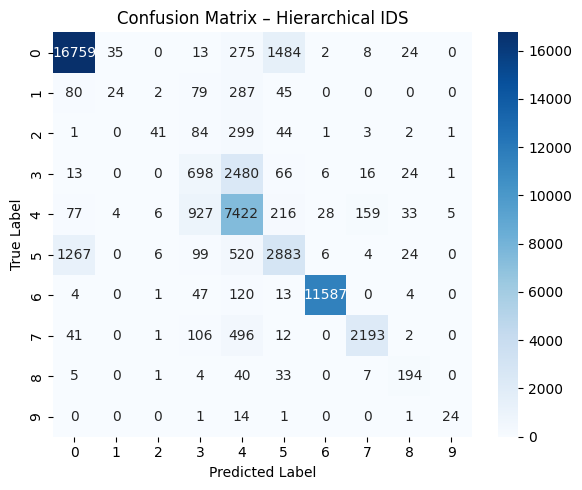

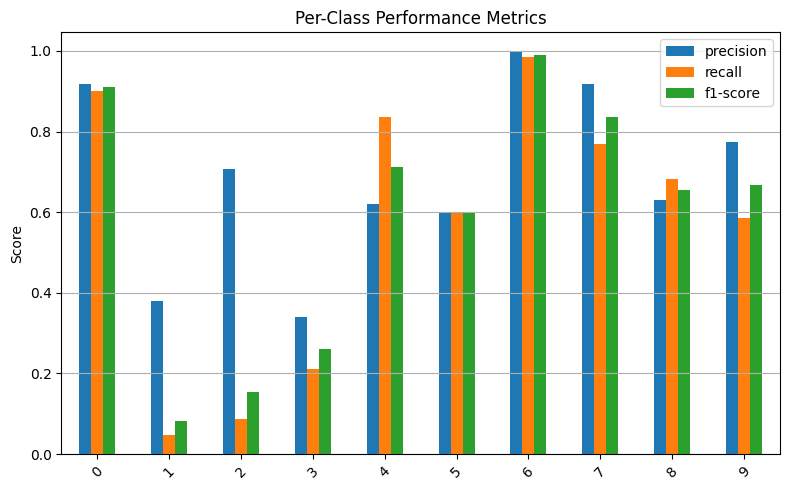

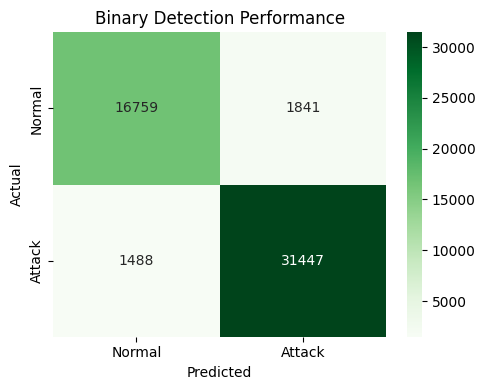

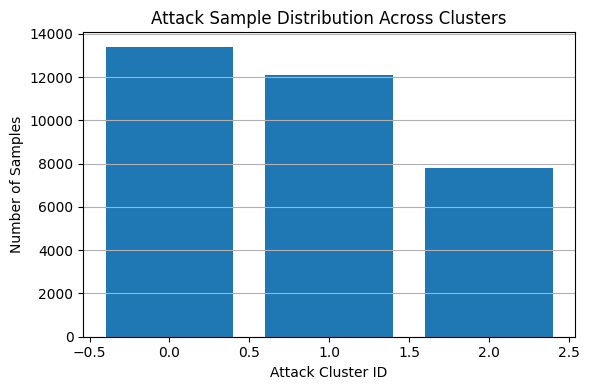

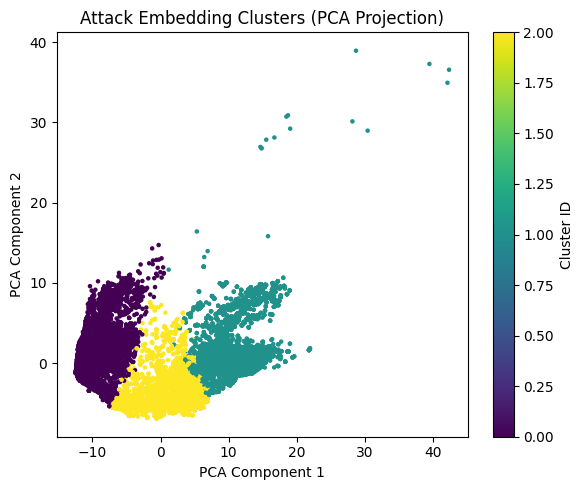

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(final_y_true, final_y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Hierarchical IDS")
plt.tight_layout()
plt.show()
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    final_y_true,
    final_y_pred,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

metrics = df_report.loc[df_report.index[:-3], ['precision', 'recall', 'f1-score']]

metrics.plot(kind='bar', figsize=(8,5))
plt.title("Per-Class Performance Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
binary_true = (final_y_true > 0).astype(int)
binary_pred = (final_y_pred > 0).astype(int)

cm_binary = confusion_matrix(binary_true, binary_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Binary Detection Performance")
plt.tight_layout()
plt.show()
unique, counts = np.unique(cluster_ids, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(unique, counts)
plt.xlabel("Attack Cluster ID")
plt.ylabel("Number of Samples")
plt.title("Attack Sample Distribution Across Clusters")
plt.grid(axis='y')
plt.tight_layout()
plt.show()
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Z_attack_2d = pca.fit_transform(Z_attack_test)

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    Z_attack_2d[:,0],
    Z_attack_2d[:,1],
    c=cluster_ids,
    s=5
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Attack Embedding Clusters (PCA Projection)")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.show()


In [33]:
# =====================================
# 1️⃣ Install SHAP (run once if needed)
# =====================================
!pip install shap

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(100, 35))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(200, 35))']
  warnings.warn(msg)


Model loaded successfully
SHAP values computed


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(10, 35))']
  warnings.warn(msg)


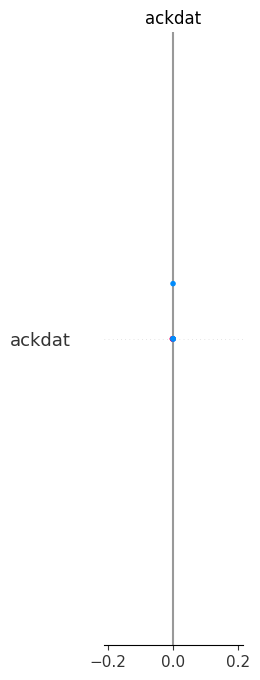

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step


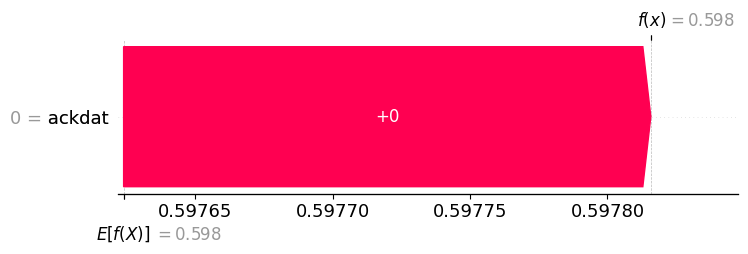

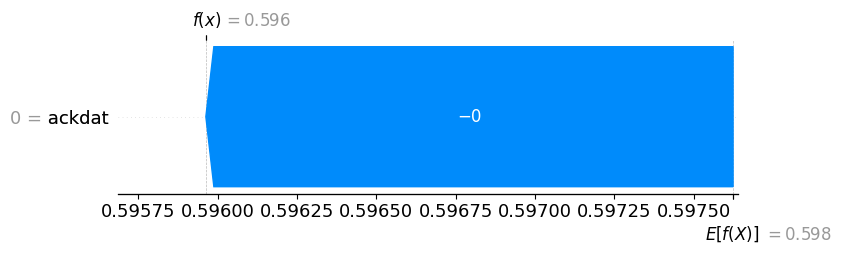

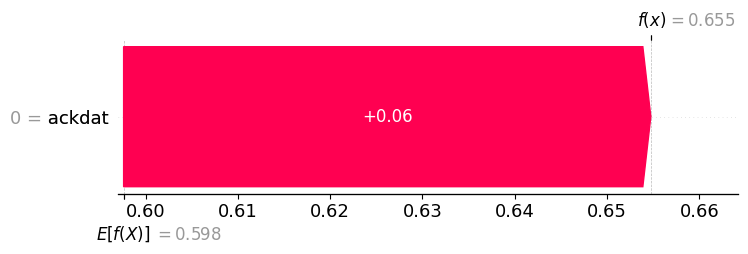

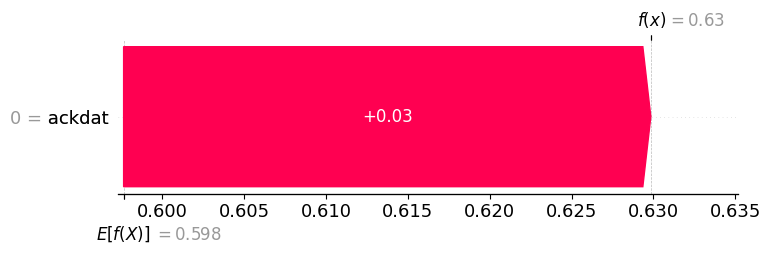

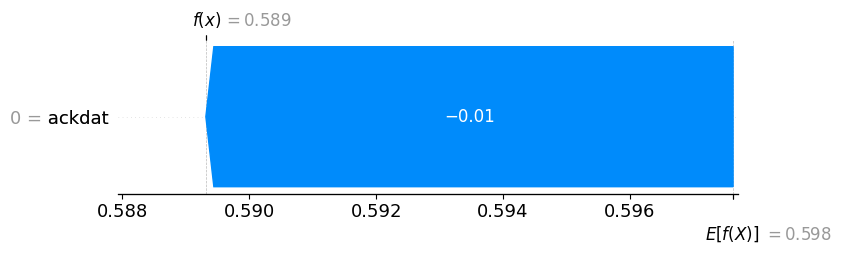

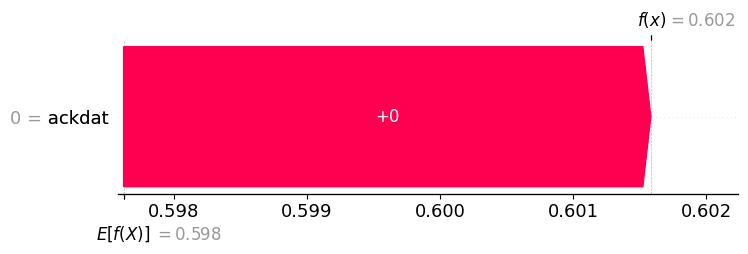

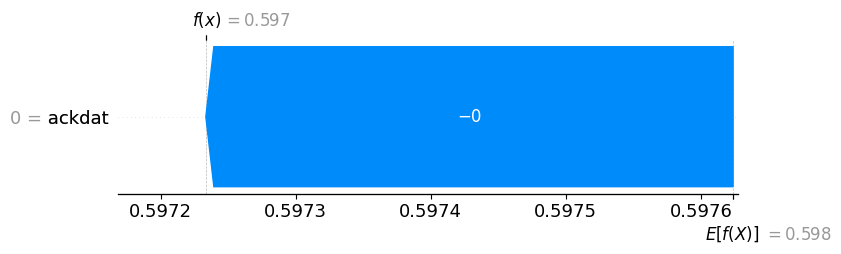

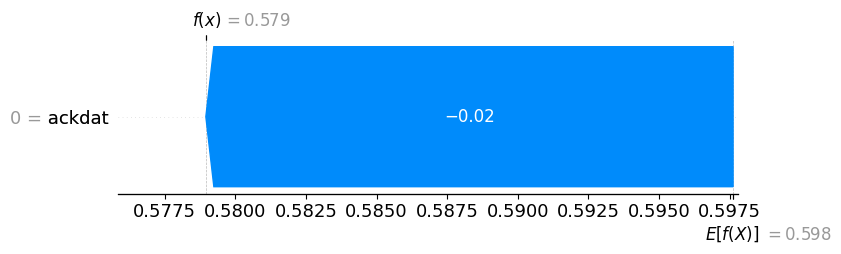

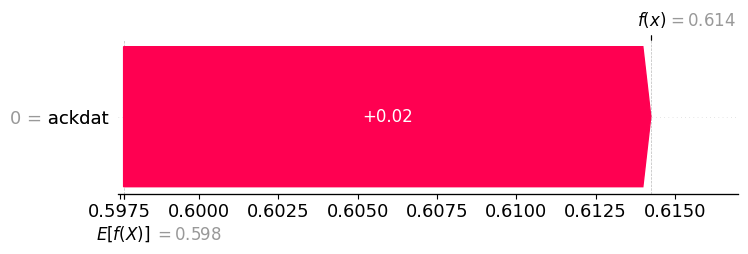

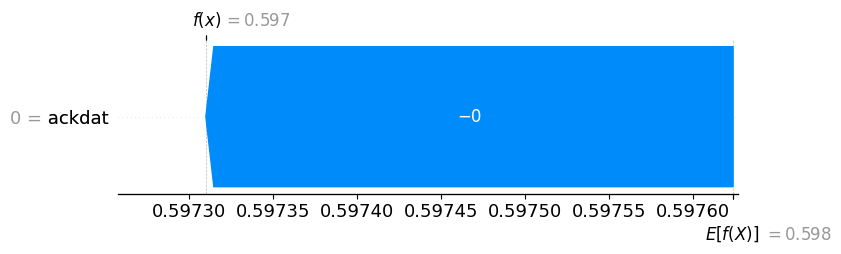

In [36]:


# =====================================
# 2️⃣ Import Libraries
# =====================================
import shap
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 3️⃣ Load Saved DNN Model
# =====================================
model_path = "/content/drive/MyDrive/Multiclass_Feature_Selection models/global_dnn_model.h5"
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

# =====================================
# 4️⃣ Select Background Data
# SHAP uses this to understand feature distribution
# =====================================
background_samples = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]

# =====================================
# 5️⃣ Select 10 Samples to Explain
# =====================================
samples_to_explain = X_test_scaled[:10]

# =====================================
# 6️⃣ Create SHAP DeepExplainer
# =====================================
explainer = shap.DeepExplainer(model, background_samples)

# =====================================
# 7️⃣ Compute SHAP Values
# =====================================
shap_values = explainer.shap_values(samples_to_explain)

print("SHAP values computed")

# =====================================
# 8️⃣ Global Feature Importance Plot
# =====================================
shap.summary_plot(
    shap_values,
    samples_to_explain,
    feature_names=selected_features   # replace if your feature list variable name differs
)

# =====================================
# 9️⃣ Local Explanation for Each Sample
# =====================================
# =====================================
# Local Explanations (10 Samples)
# =====================================

# Convert shap values to numpy if tensor
if isinstance(shap_values, list):
    shap_values = [sv.numpy() if hasattr(sv, "numpy") else sv for sv in shap_values]

predictions = model.predict(samples)

for i in range(10):

    # predicted class for sample
    pred_class = np.argmax(predictions[i])

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[pred_class][i],
            base_values=float(explainer.expected_value[pred_class]),
            data=samples[i],
            feature_names=selected_features
        )
    )

[DEBUG] START - RAM Used: 2.86 GB

Loading dataset...
Dataset shape: (82332, 45)

Loading scaler...
Scaled dataset shape: (82332, 35)
[DEBUG] After scaling - RAM Used: 2.86 GB

Splitting dataset...
Train shape: (65865, 35)
Test shape: (16467, 35)
[DEBUG] After split - RAM Used: 2.83 GB

Loading trained model...


/tmp/ipykernel_4328/2433896561.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_4328/2433896561.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_4328/2433896561.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

Model loaded successfully
Background shape: (200, 35)
Samples to explain: (10, 35)

Initializing SHAP DeepExplainer...

Computing SHAP values...
SHAP values shape: (10, 35, 1)
[DEBUG] After SHAP computation - RAM Used: 2.76 GB

Generating SHAP summary plot...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(10, 35))']
  warnings.warn(msg)


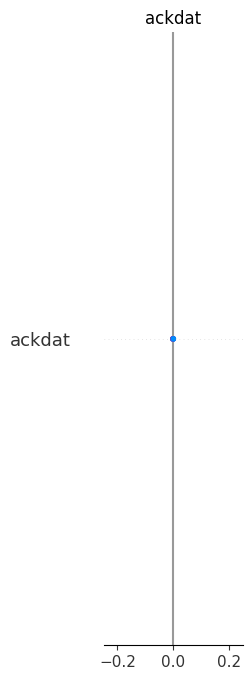


Generating feature importance plot...


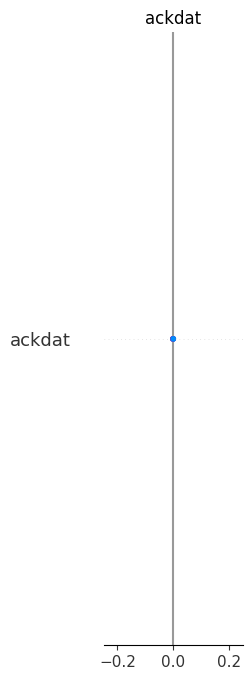


Explaining individual samples...

Sample 0 explanation


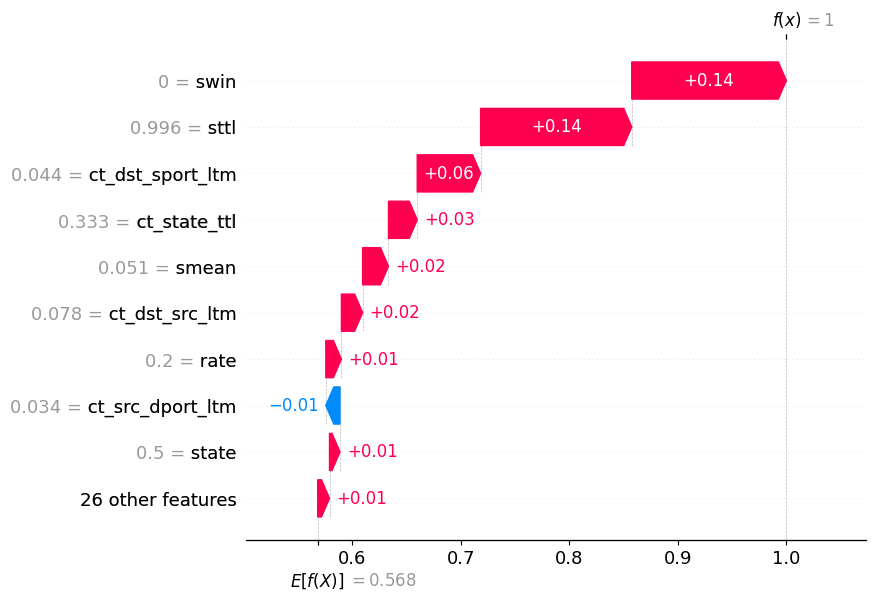


Sample 1 explanation


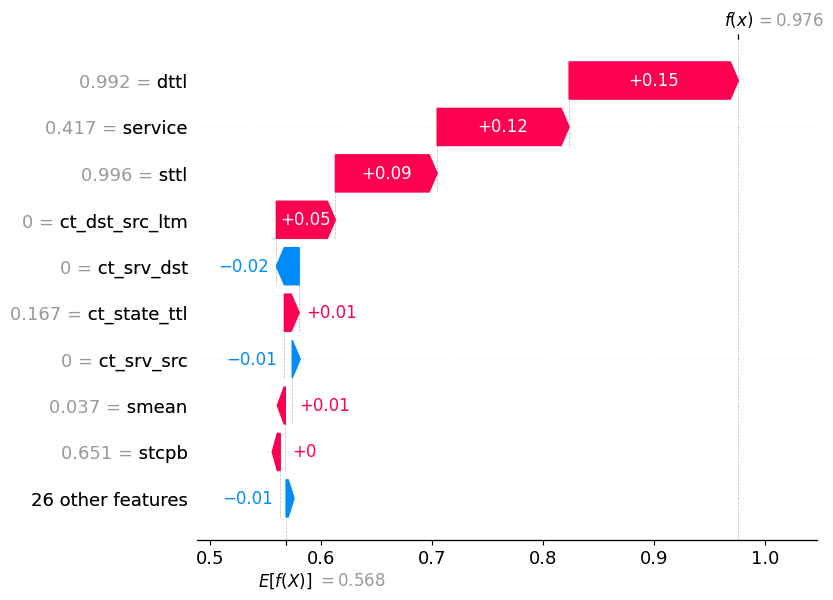


Sample 2 explanation


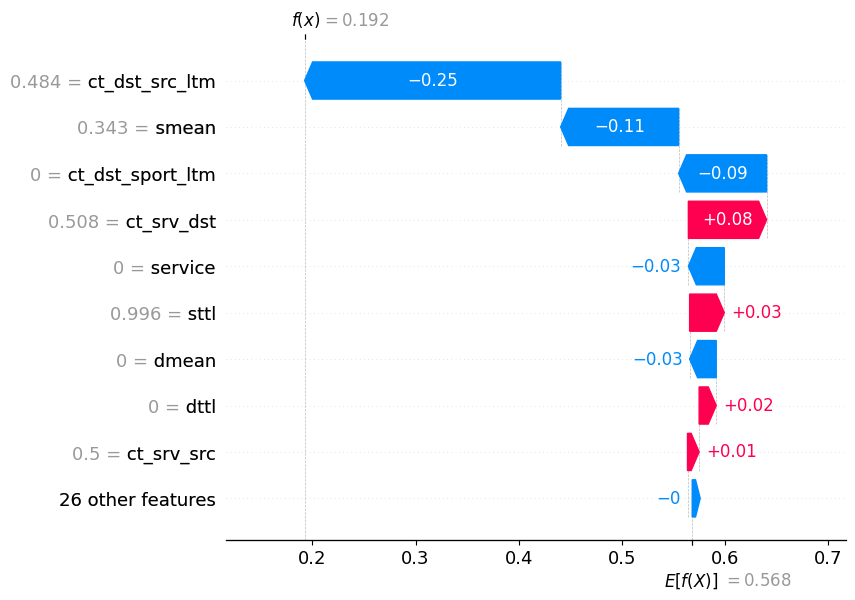


Sample 3 explanation


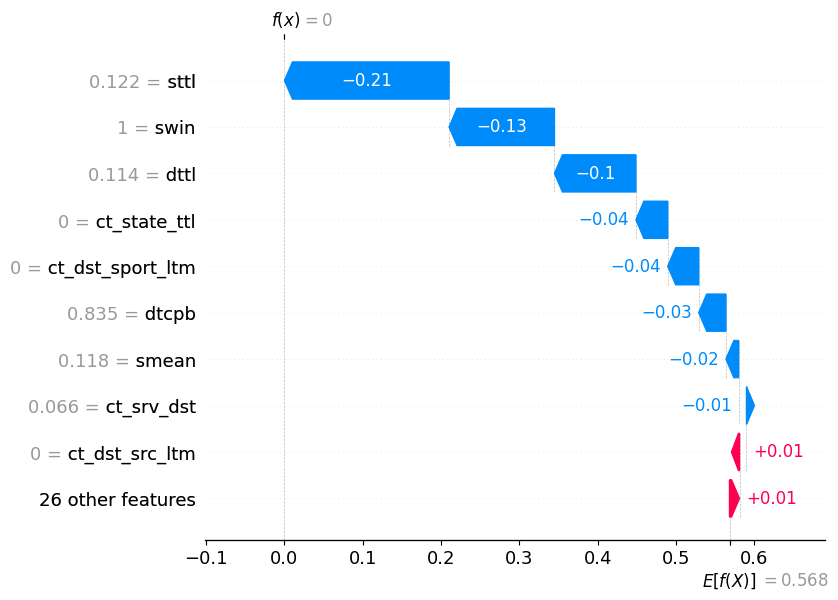


Sample 4 explanation


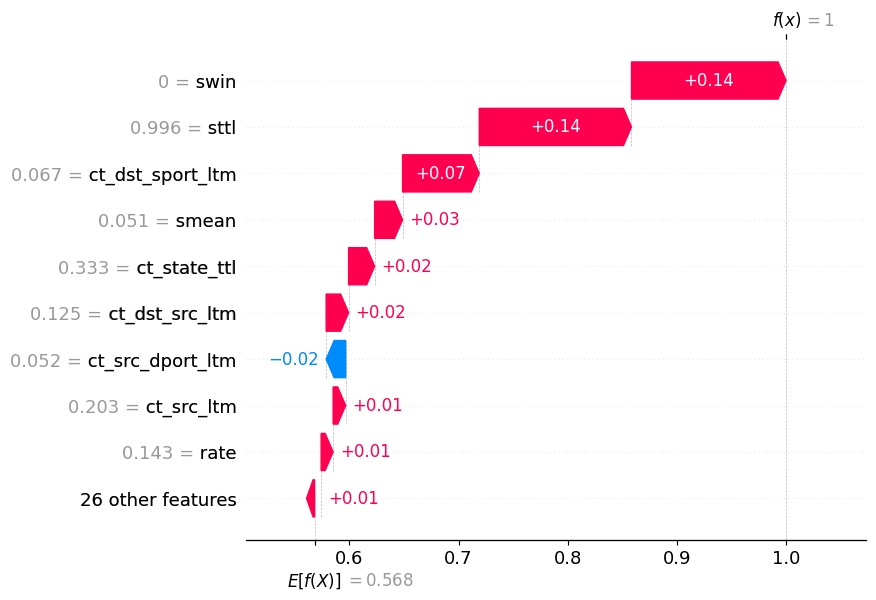


Sample 5 explanation


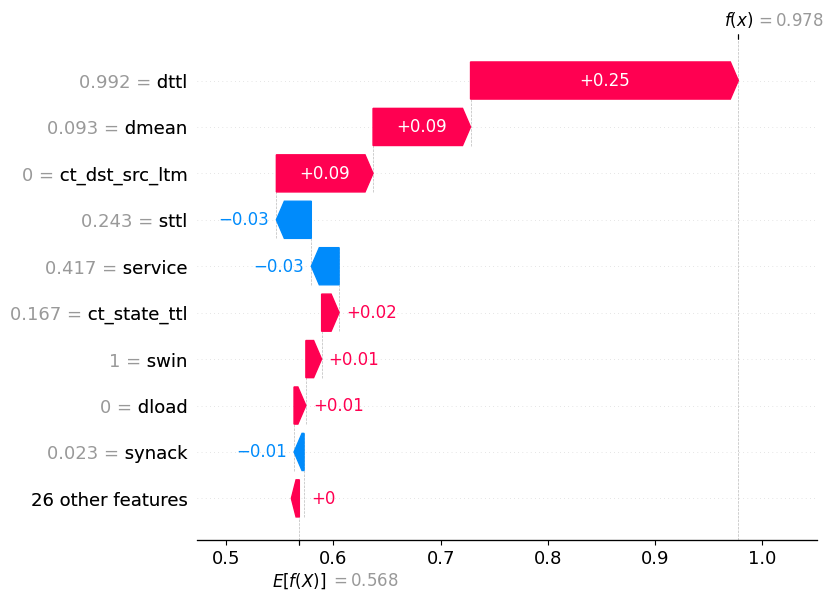


Sample 6 explanation


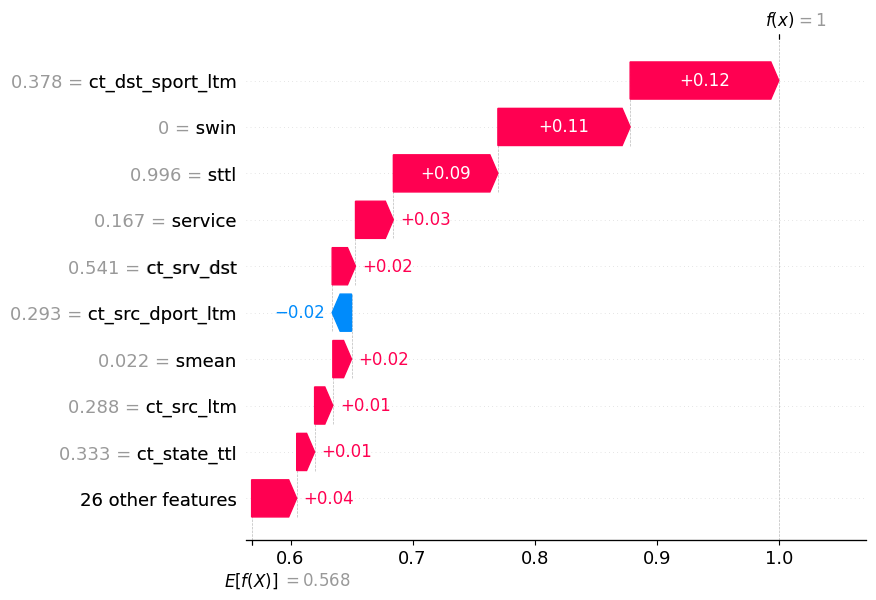


Sample 7 explanation


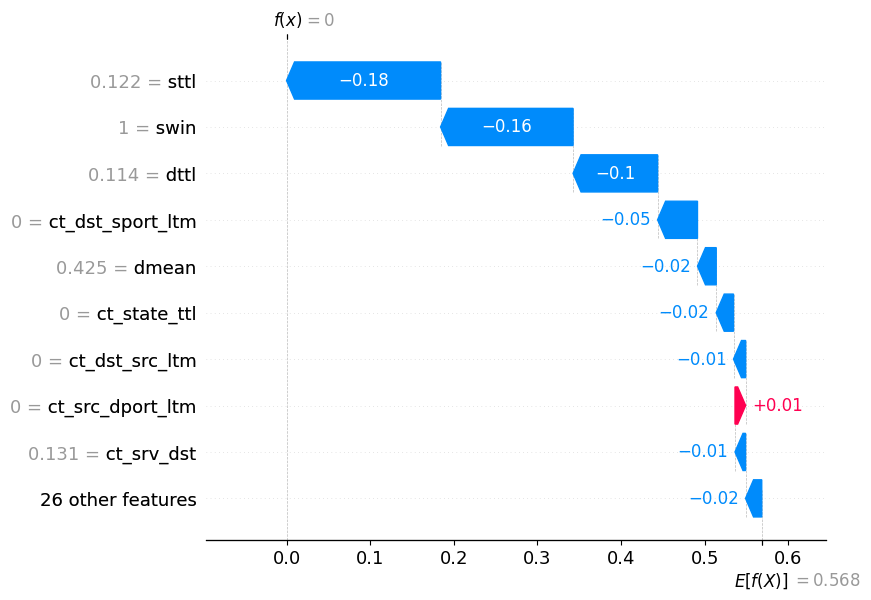


Sample 8 explanation


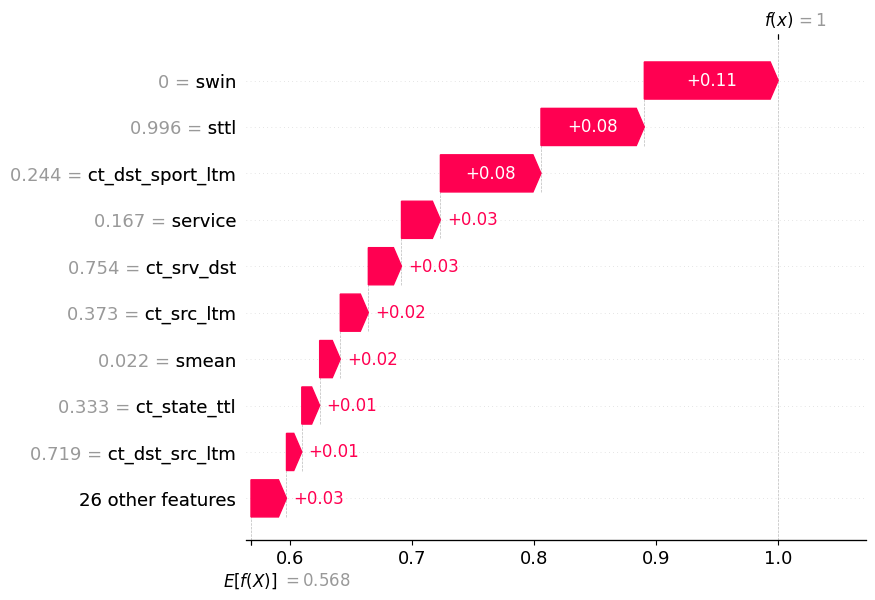


Sample 9 explanation


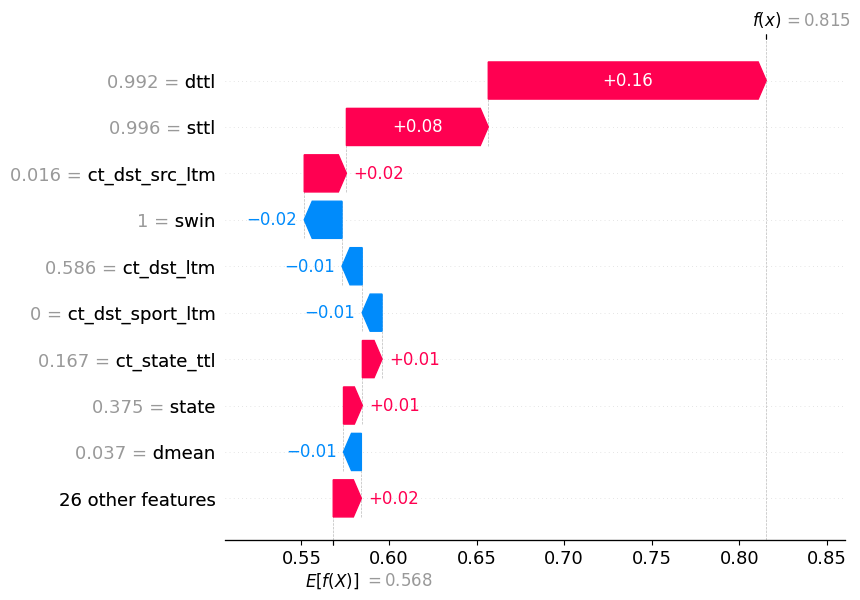


✅ SHAP explanations completed successfully


In [37]:
# ==========================================
# SHAP EXPLAINABILITY FOR DNN IDS MODEL
# ==========================================

import os
import numpy as np
import pandas as pd
import shap
import psutil
import matplotlib.pyplot as plt
from tensorflow import keras
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# -------------------------------
# Memory Debug
# -------------------------------

def print_memory(stage):
    mem = psutil.Process(os.getpid()).memory_info().rss / 1024**3
    print(f"[DEBUG] {stage} - RAM Used: {mem:.2f} GB")

print_memory("START")


# -------------------------------
# Paths
# -------------------------------
data_path = '/content/drive/MyDrive/Datasets-final/UNSW-NB15/UNSW_NB15_training-set.csv'
model_path = "/content/drive/MyDrive/Multiclass_Feature_Selection models/global_dnn_model.h5"
scaler_path = "/content/drive/MyDrive/Multiclass_Feature_Selection models/scaler.pkl"


# -------------------------------
# Selected Features
# -------------------------------

selected_features = [
'ackdat','ct_dst_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','ct_src_dport_ltm',
'ct_src_ltm','ct_srv_dst','ct_srv_src','ct_state_ttl','dbytes','dinpkt',
'djit','dload','dloss','dmean','dpkts','dtcpb','dttl','dur','proto',
'rate','sbytes','service','sinpkt','sjit','sload','sloss','smean',
'spkts','state','stcpb','sttl','swin','synack','tcprtt'
]


# -------------------------------
# Load Dataset
# -------------------------------

print("\nLoading dataset...")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)


# -------------------------------
# Drop Unnecessary Columns
# -------------------------------

df = df.drop(columns=['attack_cat','id'], errors='ignore')


# -------------------------------
# Select Features
# -------------------------------

X = df[selected_features]
y = df['label']


# -------------------------------
# Encode Categorical Features
# -------------------------------

categorical_cols = ['proto','service','state']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


# -------------------------------
# Load Scaler and Scale Data
# -------------------------------

print("\nLoading scaler...")

scaler = joblib.load(scaler_path)

X_scaled = scaler.transform(X)

print("Scaled dataset shape:", X_scaled.shape)

print_memory("After scaling")


# -------------------------------
# Train/Test Split
# -------------------------------

print("\nSplitting dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print_memory("After split")


# -------------------------------
# Load Trained Model
# -------------------------------

print("\nLoading trained model...")

model = keras.models.load_model(model_path)

print("Model loaded successfully")


# -------------------------------
# Background Samples
# -------------------------------

background_size = 200

background = X_train[
    np.random.choice(X_train.shape[0], background_size, replace=False)
]

print("Background shape:", background.shape)


# -------------------------------
# Samples to Explain
# -------------------------------

samples_to_explain = 10

X_explain = X_test[:samples_to_explain]

print("Samples to explain:", X_explain.shape)


# -------------------------------
# Initialize SHAP Explainer
# -------------------------------

print("\nInitializing SHAP DeepExplainer...")

explainer = shap.DeepExplainer(model, background)


# -------------------------------
# Compute SHAP Values
# -------------------------------

print("\nComputing SHAP values...")

shap_values = explainer.shap_values(X_explain)

# For multiclass models
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

print_memory("After SHAP computation")


# -------------------------------
# Fix expected value
# -------------------------------

expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[0]

expected_value = float(expected_value)


# -------------------------------
# Global Feature Importance
# -------------------------------

print("\nGenerating SHAP summary plot...")

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=selected_features,
    show=True
)


# -------------------------------
# Feature Importance Bar Plot
# -------------------------------

print("\nGenerating feature importance plot...")

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=selected_features,
    plot_type="bar"
)


# -------------------------------
# Local Explanations
# -------------------------------

print("\nExplaining individual samples...")

for i in range(samples_to_explain):

    print(f"\nSample {i} explanation")

    explanation = shap.Explanation(
        values=shap_values[i].flatten(),
        base_values=expected_value,
        data=X_explain[i],
        feature_names=selected_features
    )

    shap.plots.waterfall(explanation)


print("\n✅ SHAP explanations completed successfully")